# CHiME-6 Data Collection and Audio Processing

Download and process the official CHiME-6 corpus (OpenSLR-150), run a DSP
enhancement pipeline (phases 1-8) over the real 4-channel Kinect arrays, and
export frame-level features with speech/noise labels to CSV for an LSTM.


## Imports


In [ ]:
import os
import re
import csv
import json
import logging
import subprocess
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from scipy import special

import torch
from torch.utils.data import DataLoader, Dataset

from IPython.display import Audio, display

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

## Download the CHiME-6 dataset (OpenSLR-150)

The official corpus ships the Kinect arrays (6 arrays x 4 channels) plus the
official train/dev/eval splits, so the pipeline uses 4 real channels instead of
simulating channels with Gaussian noise. After extraction the layout is:

```
<root>/.../audio/{train,dev,eval}/S0X_U0Y.CHZ.wav     (one mono file per channel)
<root>/.../transcriptions/{train,dev,eval}/S0X.json   (SegLST per session)
```


In [ ]:
# Parameters
CHIME6_ROOT = Path("/content/drive/MyDrive/chime6")        # destination
SPLITS = ["dev", "eval"]                                    # use "train", "dev", "eval"
MIRROR_BASE = "https://openslr.trmal.net/resources/150"     # EU: openslr.elda.org | CN: openslr.magicdatatech.com

TARBALLS = {
    "train": "CHiME6_train.tar.gz",   # 97G
    "dev":   "CHiME6_dev.tar.gz",     # 11G
    "eval":  "CHiME6_eval.tar.gz",    # 12G
}

# Mount Google Drive on Colab; otherwise use CHIME6_ROOT as-is.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print(f"Drive not mounted - assuming CHIME6_ROOT exists locally: {e}")

CHIME6_ROOT.mkdir(parents=True, exist_ok=True)


def _audio_files_for_split(split):
    """Extracted .CH1.wav files whose path contains the split directory."""
    return [p for p in CHIME6_ROOT.rglob("*.CH1.wav") if split in p.parts]


def _download_extract(url, resume_dir=None):
    """Download (resumable with -c) and extract a tarball into CHIME6_ROOT.

    resume_dir=None  -> download to /content (fast local disk) and extract.
    resume_dir=path  -> download to that dir (on Drive, resumable) and extract;
                        used for the 97G train tarball that does not fit on the
                        local disk.
    """
    fname = Path(url).name
    if resume_dir is not None:
        resume_dir.mkdir(parents=True, exist_ok=True)
        local = resume_dir / fname
    else:
        local = Path("/content") / fname
    subprocess.run(["wget", "-c", url, "-O", str(local)], check=True)
    subprocess.run(["tar", "-xzf", str(local), "-C", str(CHIME6_ROOT)], check=True)
    return local


# Transcriptions are always needed for the labels.
if not any(CHIME6_ROOT.rglob("transcriptions/**/*.json")):
    print("Downloading transcriptions...")
    _download_extract(f"{MIRROR_BASE}/CHiME6_transcriptions.tar.gz")
else:
    print("Transcriptions already present")

for split in SPLITS:
    if _audio_files_for_split(split):
        print(f"Audio '{split}' already present - skipping download")
        continue
    url = f"{MIRROR_BASE}/{TARBALLS[split]}"
    # train is too large for the local disk -> download resumably onto Drive
    resume_dir = (CHIME6_ROOT / "_tarballs") if split == "train" else None
    print(f"Downloading '{split}' from {url} ...")
    _download_extract(url, resume_dir=resume_dir)
    print(f"'{split}' extracted")

print(f"\nCHiME-6 ready at: {CHIME6_ROOT}")
for split in SPLITS:
    print(f"  {split}: {len(_audio_files_for_split(split))} .CH1.wav files")
# Tip: once extraction is confirmed you can delete CHIME6_ROOT/_tarballs.

Mounted at /content/drive
Transcriptions already present
Audio 'dev' already present - skipping download
Audio 'eval' already present - skipping download

CHiME-6 ready at: /content/drive/MyDrive/chime6
  dev: 11 .CH1.wav files
  eval: 11 .CH1.wav files


## Audio helper functions


In [ ]:
def extract_segment(audio, sr, start_sec, duration_sec):
    """Slice [start_sec, start_sec + duration_sec) out of an audio array."""
    start = int(start_sec * sr)
    end = int((start_sec + duration_sec) * sr)
    return audio[start:end]


def compute_mel_spectrogram(audio, sr, n_mels=128, n_fft=2048, hop_length=512):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels,
                                         n_fft=n_fft, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max)


def compute_mfcc(audio, sr, n_mfcc=13):
    return librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)


def audio_statistics(audio):
    return {
        "min": float(np.min(audio)),
        "max": float(np.max(audio)),
        "mean": float(np.mean(audio)),
        "std": float(np.std(audio)),
        "rms": float(np.sqrt(np.mean(audio ** 2))),
    }

## Build the recording manifest


In [ ]:
# Build the manifest: one recording per (session x reference array). Each
# recording is one 4-channel Kinect array of a session, plus the speech
# intervals extracted from that session's transcription (.json).

SR = 16000
REF_ARRAY_PREFERENCE = ["U06", "U05", "U04", "U03", "U02", "U01"]  # first available wins


def _parse_chime6_time(t):
    """'H:MM:SS.SS' (or a number) -> seconds (float)."""
    if isinstance(t, (int, float)):
        return float(t)
    sec = 0.0
    for part in str(t).split(":"):
        sec = sec * 60.0 + float(part)
    return sec


def _extract_time(field, ref_array=None):
    """start_time/end_time may be a string or, in older variants, a per-array
    dict (CHiME-5 clock drift). Pick the reference array when it is a dict."""
    if isinstance(field, dict):
        field = field.get(ref_array, next(iter(field.values())))
    return _parse_chime6_time(field)


def load_session_speech_intervals(json_path, ref_array=None):
    """Read a CHiME-6 SegLST .json -> (starts, ends) in seconds.

    Every transcribed utterance counts as speech. To exclude noise-only
    segments, filter on u['words'] here (e.g. skip empty or [noise]-only ones).
    """
    with open(json_path, "r", encoding="utf-8") as fh:
        utterances = json.load(fh)
    starts, ends = [], []
    for u in utterances:
        if "start_time" not in u or "end_time" not in u:
            continue
        starts.append(_extract_time(u["start_time"], ref_array))
        ends.append(_extract_time(u["end_time"], ref_array))
    return starts, ends


def _find_transcript(session_id, split):
    cands = [p for p in CHIME6_ROOT.rglob(f"{session_id}.json")
             if "transcription" in str(p).lower() and split in p.parts]
    if not cands:
        cands = list(CHIME6_ROOT.rglob(f"{session_id}.json"))
    return cands[0] if cands else None


recordings = []
for split in SPLITS:
    # Group the CH1 files by session to discover which arrays exist.
    sessions = {}
    for p in CHIME6_ROOT.rglob("*.CH1.wav"):
        if split not in p.parts:
            continue
        m = re.match(r"(S\d+)_(U\d+)\.CH1\.wav$", p.name)
        if m:
            sessions.setdefault(m.group(1), {})[m.group(2)] = p

    for sess, arrays in sorted(sessions.items()):
        arr = next((a for a in REF_ARRAY_PREFERENCE if a in arrays), sorted(arrays)[0])
        ch1 = arrays[arr]
        channel_paths = [ch1.with_name(f"{sess}_{arr}.CH{c}.wav") for c in range(1, 5)]
        channel_paths = [p for p in channel_paths if p.exists()]
        if len(channel_paths) < 4:
            print(f"  Warning: {sess}_{arr} has only {len(channel_paths)}/4 channels - skipping")
            continue

        tpath = _find_transcript(sess, split)
        if tpath is None:
            print(f"  Warning: transcript for {sess} not found - skipping")
            continue
        starts, ends = load_session_speech_intervals(tpath, ref_array=arr)

        info = sf.info(str(channel_paths[0]))
        recordings.append({
            "session_id": sess,
            "split": split,
            "array": arr,
            "channel_paths": [str(p) for p in channel_paths],
            "timestamps_start": starts,
            "timestamps_end": ends,
            "duration_sec": info.frames / info.samplerate,
        })

print(f"{len(recordings)} recordings in the manifest:")
for r in recordings:
    print(f"  [{r['split']:5s}] {r['session_id']}_{r['array']} | "
          f"{r['duration_sec']/60:.1f} min | {len(r['timestamps_start'])} utterances")

# Convenience aliases for the inspection/demo cells below:
#   audio_files -> manifest; audio/sr -> 60s mono preview of the first CH1.
audio_files = recordings
if recordings:
    audio, sr = sf.read(recordings[0]["channel_paths"][0],
                        start=0, stop=60 * SR, dtype="float32")
    if audio.ndim > 1:
        audio = audio[:, 0]
else:
    audio, sr = None, SR
    print("Warning: no recordings found - check SPLITS and the extraction.")

4 recordings in the manifest:
  [dev  ] S02_U06 | 148.4 min | 3822 utterances
  [dev  ] S09_U06 | 119.4 min | 3615 utterances
  [eval ] S01_U06 | 159.1 min | 5797 utterances
  [eval ] S21_U06 | 153.3 min | 5231 utterances


## Inspect the first recording


In [ ]:
# 60s mono preview of CH1 of the first recording.
if audio_files and audio is not None:
    rec0 = audio_files[0]
    print(f"Inspecting {rec0['session_id']}_{rec0['array']} "
          f"(split={rec0['split']}) - channel CH1, {len(audio)/sr:.0f}s preview")
    print(f"Full recording duration: {rec0['duration_sec']/60:.1f} min")
    print(f"Preview: sample rate {sr} Hz, duration {len(audio)/sr:.2f} s, shape {audio.shape}")
    print("Statistics:")
    for key, value in audio_statistics(audio).items():
        print(f"  {key}: {value:.4f}")
else:
    print("No audio files available to load.")

Inspecting S02_U06 (split=dev) - channel CH1, 60s preview
Full recording duration: 148.4 min
Preview: sample rate 16000 Hz, duration 60.00 s, shape (960000,)
Statistics:
  min: -0.5797
  max: 0.6873
  mean: -0.0000
  std: 0.0303
  rms: 0.0303


## Listen to an audio sample

Adjust `listen_duration_sec` to choose how many seconds to play.


In [ ]:
if audio_files and audio is not None:
    listen_duration_sec = 3.0  # seconds to play
    audio_segment = extract_segment(audio, sr, start_sec=0, duration_sec=listen_duration_sec)
    print(f"Playing {listen_duration_sec} seconds of audio...")
    display(Audio(data=audio_segment, rate=sr))

Playing 3.0 seconds of audio...


## Extract mel-spectrogram and MFCC features


In [ ]:
if audio is not None:
    mel_spec = compute_mel_spectrogram(audio, sr, n_mels=128)
    print(f"Mel spectrogram: {mel_spec.shape} "
          f"({mel_spec.shape[0]} mel bins, {mel_spec.shape[1]} frames)")

    mfcc = compute_mfcc(audio, sr, n_mfcc=13)
    print(f"MFCC: {mfcc.shape} ({mfcc.shape[0]} coefficients, {mfcc.shape[1]} frames)")

Mel spectrogram: (128, 1876) (128 mel bins, 1876 frames)
MFCC: (13, 1876) (13 coefficients, 1876 frames)


## Visualize the features


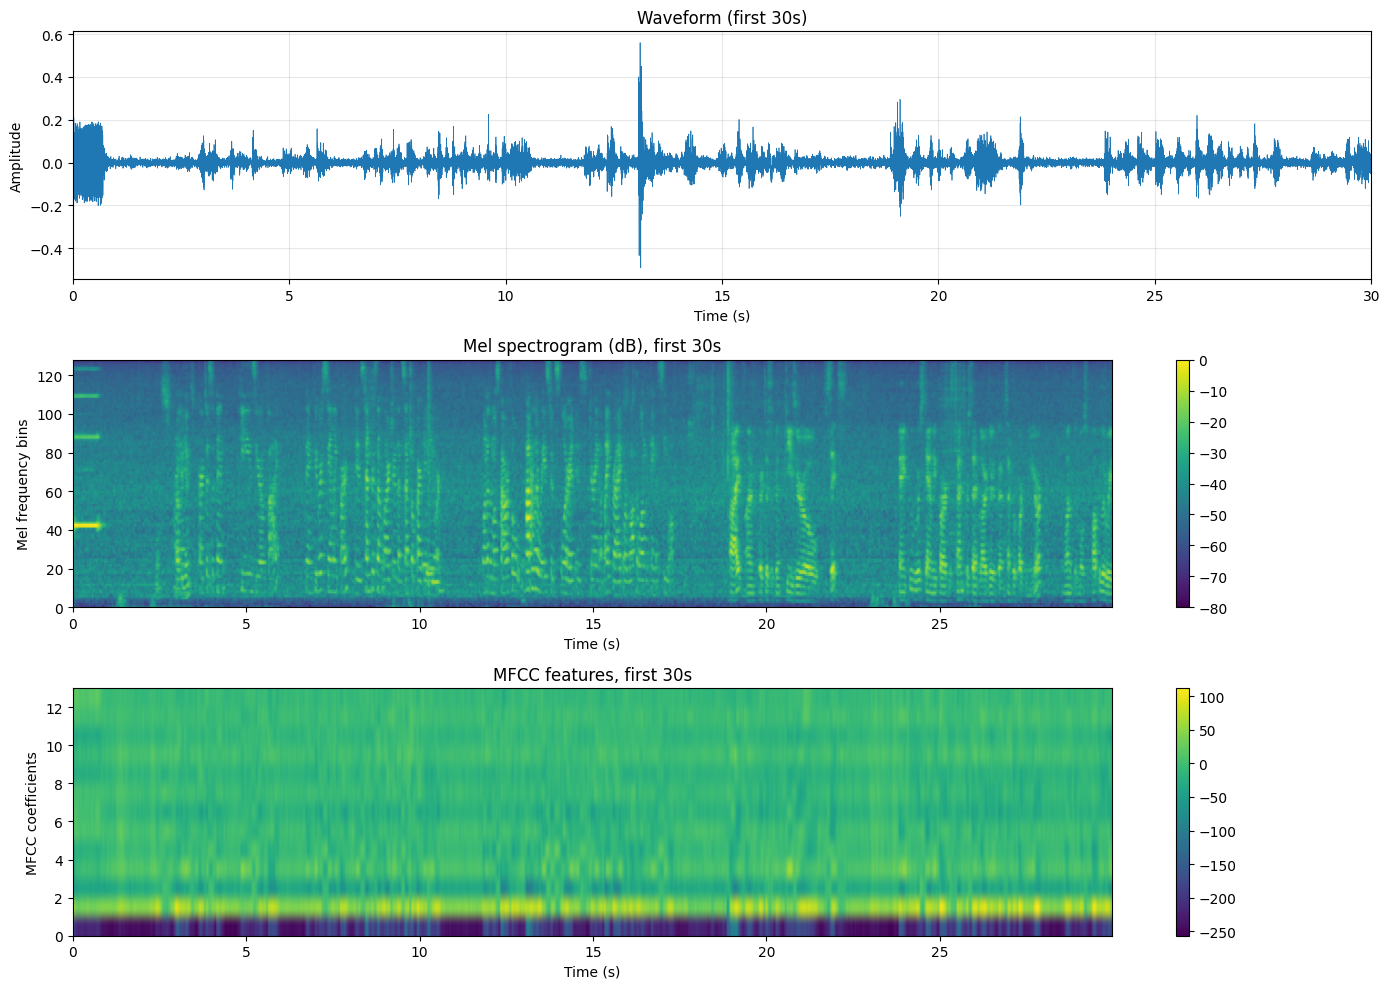

In [ ]:
if audio is not None and mel_spec is not None:
    # Cap the window to keep RAM and matplotlib happy on Colab.
    MAX_DURATION_SEC = 30.0
    MAX_PLOT_POINTS = 25000
    hop_length = 512

    max_samples = int(MAX_DURATION_SEC * sr)
    max_frames = int(librosa.time_to_frames(MAX_DURATION_SEC, sr=sr, hop_length=hop_length))

    audio_trunc = audio[:max_samples]
    mel_spec_trunc = mel_spec[:, :max_frames]
    mfcc_trunc = mfcc[:, :max_frames]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    time_steps = np.arange(mel_spec_trunc.shape[1])
    time_sec = librosa.frames_to_time(time_steps, sr=sr, hop_length=hop_length)

    # Waveform, downsampled so matplotlib never draws more than MAX_PLOT_POINTS.
    time_audio = np.arange(len(audio_trunc)) / sr
    downsample = max(1, len(audio_trunc) // MAX_PLOT_POINTS)
    axes[0].plot(time_audio[::downsample], audio_trunc[::downsample], linewidth=0.5)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Waveform (first {MAX_DURATION_SEC:.0f}s)")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, MAX_DURATION_SEC)

    im = axes[1].imshow(mel_spec_trunc, aspect="auto", origin="lower",
                        extent=[time_sec[0], time_sec[-1], 0, mel_spec_trunc.shape[0]])
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Mel frequency bins")
    axes[1].set_title(f"Mel spectrogram (dB), first {MAX_DURATION_SEC:.0f}s")
    plt.colorbar(im, ax=axes[1])

    im = axes[2].imshow(mfcc_trunc, aspect="auto", origin="lower",
                        extent=[time_sec[0], time_sec[-1], 0, mfcc_trunc.shape[0]])
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("MFCC coefficients")
    axes[2].set_title(f"MFCC features, first {MAX_DURATION_SEC:.0f}s")
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

## Preview summary of the manifest


In [ ]:
# Read only a short preview (CH1) of each recording to exercise feature
# extraction without loading full ~2.5h arrays into memory.
def summarize_recordings(recordings, max_recordings=5, preview_sec=30.0, segment_duration=10.0):
    rows = []
    for rec in recordings[:max_recordings]:
        try:
            prev, sr = sf.read(rec["channel_paths"][0], start=0,
                               stop=int(preview_sec * SR), dtype="float32")
            if prev.ndim > 1:
                prev = prev[:, 0]

            n_segments = max(1, int(np.ceil((len(prev) / sr) / segment_duration)))
            for seg_idx in range(n_segments):
                seg = extract_segment(prev, sr, seg_idx * segment_duration, segment_duration)
                if len(seg) >= sr:
                    compute_mel_spectrogram(seg, sr)  # exercise the extractor

            rows.append({
                "recording": f"{rec['session_id']}_{rec['array']}",
                "split": rec["split"],
                "full_duration_min": round(rec["duration_sec"] / 60.0, 1),
                "preview_sec": round(min(preview_sec, rec["duration_sec"]), 1),
                "utterances": len(rec["timestamps_start"]),
            })
        except Exception as e:
            print(f"  Error on {rec.get('session_id')}: {e}")
    return rows


if audio_files:
    summary = summarize_recordings(audio_files, max_recordings=5)
    if summary:
        print("Preview summary of the first recordings:")
        print(pd.DataFrame(summary).to_string(index=False))
else:
    print("No recordings in the manifest")

Preview summary of the first recordings:
recording split  full_duration_min  preview_sec  utterances
  S02_U06   dev              148.4         30.0        3822
  S09_U06   dev              119.4         30.0        3615
  S01_U06  eval              159.1         30.0        5797
  S21_U06  eval              153.3         30.0        5231


## Memory-safe waveform plot


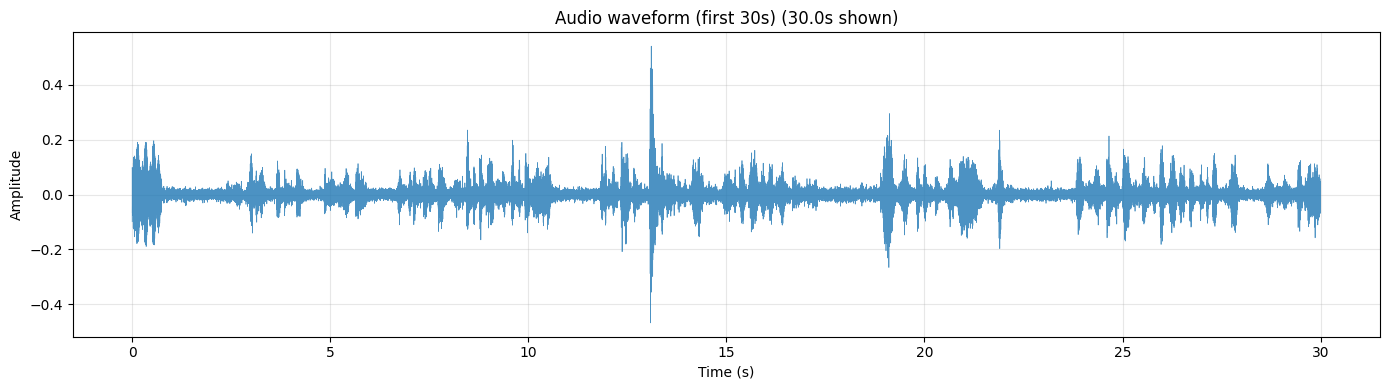

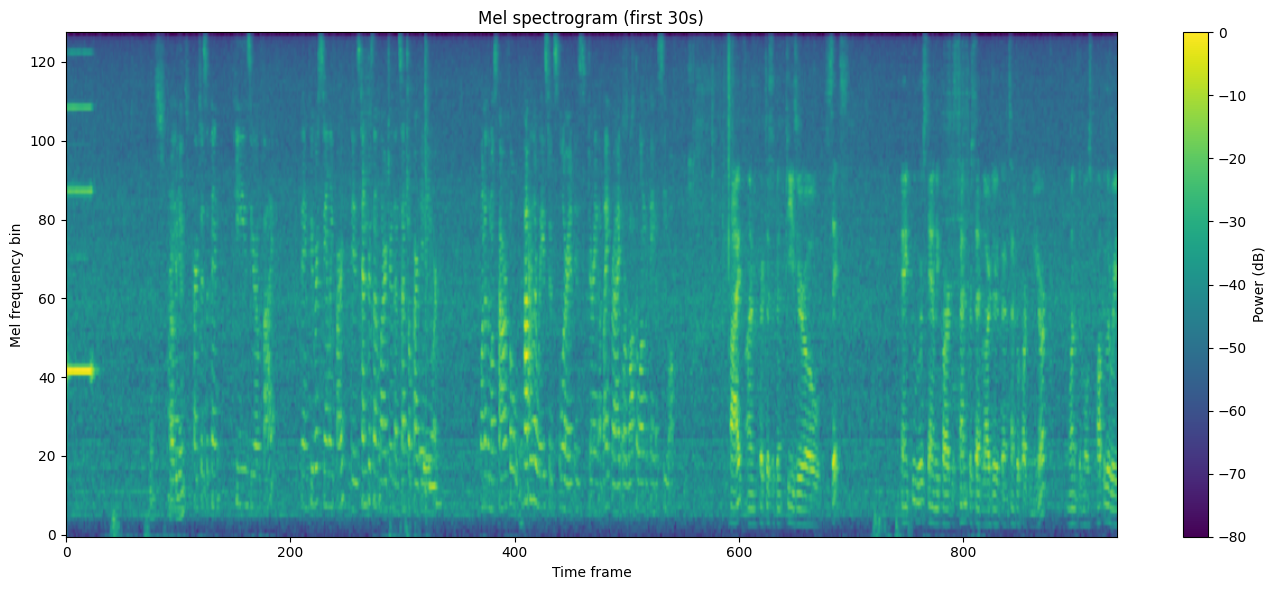

In [ ]:
def plot_audio_safely(audio, sr, title="Audio", max_duration_sec=30.0, downsample_factor=4):
    """Plot a waveform, truncating and downsampling to avoid memory blow-ups."""
    max_samples = int(max_duration_sec * sr)
    audio_plot = audio[:max_samples][::downsample_factor]
    time_seconds = np.arange(len(audio_plot)) * downsample_factor / sr

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time_seconds, audio_plot, linewidth=0.5, alpha=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"{title} ({len(audio_plot) * downsample_factor / sr:.1f}s shown)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


if audio is not None:
    plot_audio_safely(audio, sr, title="Audio waveform (first 30s)",
                      max_duration_sec=30.0, downsample_factor=8)
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 6))
    n_frames = int(mel_spec.shape[1] * min(1.0, 30.0 * sr / len(audio)))
    im = ax.imshow(mel_spec[:, :n_frames], aspect="auto", origin="lower", cmap="viridis")
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel frequency bin")
    ax.set_title("Mel spectrogram (first 30s)")
    plt.colorbar(im, ax=ax, label="Power (dB)")
    plt.tight_layout()
    plt.show()
else:
    print("No audio loaded for visualization")

## DSP pipeline (phases 1-8)

The enhancement pipeline is a set of plain functions, run end to end by
`run_complete_dsp_pipeline`. Stages:

1. **Phase 1-3** - multi-channel STFT, noise-floor estimate and SNR-based
   channel selection.
2. **Phase 4** - time-frequency glimpse extraction (high-SNR, speech-dominant bins).
3. **Phase 5-6** - IMCRA noise tracking and Log-MMSE enhancement.
4. **Phase 7** - multiband spectral subtraction.
5. **Phase 8** - feature extraction (log-mel, beamformed STFT, spatial energy).

In [ ]:
# Phase 1-3: multi-channel STFT, noise estimate, SNR-based channel selection.

def compute_stft_multichannel(multi_channel, n_fft=512, hop_length=128):
    """(n_channels, n_samples) -> magnitude STFT (n_channels, n_freq, n_frames)."""
    return np.array([np.abs(librosa.stft(ch, n_fft=n_fft, hop_length=hop_length))
                     for ch in multi_channel])


def estimate_noise_power(stft, percentile=10):
    """Per-(channel, freq) noise floor = low percentile of power across frames."""
    return np.percentile(stft ** 2, percentile, axis=2)  # (n_channels, n_freq)


def compute_snr_per_channel(stft, noise_power):
    """Mean SNR (dB) per channel."""
    signal_power = np.mean(stft ** 2, axis=2)  # (n_channels, n_freq)
    snr_db = 10 * np.log10(signal_power / (noise_power + 1e-8))
    return np.mean(snr_db, axis=1)


def select_best_channels(snr, threshold_ratio=1.0):
    """Boolean mask of channels at or above threshold_ratio * mean SNR."""
    return snr >= threshold_ratio * np.mean(snr)

In [ ]:
# Phase 4: time-frequency glimpse extraction (high-SNR speech-dominant bins).

def extract_glimpses(stft, noise_power, snr_threshold_db=3.0):
    """Boolean (n_freq, n_frames) mask where per-bin SNR exceeds the threshold.
    Multi-channel inputs are averaged across channels first."""
    if stft.ndim == 3:
        stft = np.mean(stft, axis=0)
    if noise_power.ndim == 2:
        noise_power = np.mean(noise_power, axis=0)
    snr_db = 10 * np.log10((stft ** 2 + 1e-8) / (noise_power[:, None] + 1e-8))
    return snr_db > snr_threshold_db


def glimpse_statistics(mask):
    total = int(np.prod(mask.shape))
    glimpses = int(np.sum(mask))
    return {
        "total_bins": total,
        "glimpse_bins": glimpses,
        "coverage": 100.0 * glimpses / total,
        "n_freq": mask.shape[0],
        "n_frames": mask.shape[1],
    }

In [ ]:
# Phases 6-7: noise tracking, enhancement, spectral subtraction.

def track_noise(stft, update_rate=0.05):
    """IMCRA-style adaptive noise power tracking -> (n_freq, n_frames).
    Multi-channel inputs are averaged across channels first."""
    if stft.ndim == 3:
        stft = np.mean(stft, axis=0)
    power = stft ** 2
    noise = np.zeros_like(power)
    noise[:, 0] = np.mean(power[:, :min(5, power.shape[1])], axis=1)
    for f in range(1, power.shape[1]):
        noise[:, f] = (1 - update_rate) * noise[:, f - 1] + update_rate * power[:, f]
    return noise


def posterior_snr(stft, noise_spectrum):
    return stft ** 2 / (noise_spectrum + 1e-8)


def log_mmse_enhance(stft, post_snr, prior_snr=None):
    """Apply an approximate Log-MMSE gain to the STFT magnitude."""
    if prior_snr is None:
        prior_snr = np.full_like(post_snr, 0.5)
    gamma = post_snr
    xi = prior_snr * gamma / (1 + prior_snr)
    gain = xi / (1 + xi) * np.exp(special.loggamma((gamma + 1) / 2) -
                                  special.loggamma(gamma / 2))
    return stft * np.clip(gain, 0, 1)


def multiband_spectral_subtraction(stft, noise_spectrum, n_bands=10, subtraction_factor=2.0):
    """Frequency-dependent spectral subtraction with SNR-adaptive strength per band."""
    n_freq = stft.shape[0]
    freq_per_band = n_freq // n_bands
    out = np.zeros_like(stft)
    for band in range(n_bands):
        start = band * freq_per_band
        end = (band + 1) * freq_per_band if band < n_bands - 1 else n_freq
        snr = np.mean(stft[start:end]) / (np.mean(noise_spectrum[start:end]) + 1e-8)
        alpha = subtraction_factor / (1 + snr)
        out[start:end] = np.maximum(0, stft[start:end] - alpha * noise_spectrum[start:end])
    return out

In [ ]:
# Phase 8: feature extraction for the neural model.

def extract_log_mel_spectrogram(stft, sr=16000, n_fft=512, n_mels=128):
    mel_fb = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)
    return librosa.power_to_db(mel_fb @ (stft ** 2), ref=np.max)


def extract_features(multi_channel, enhanced_stft=None, sr=16000, n_fft=512,
                     hop_length=128, n_mels=128):
    """Extract features from multi-channel audio.

    Returns log-mel (from the enhanced STFT when given, else the beamformed
    STFT), the beamformed magnitude STFT, per-channel spatial energy, the
    per-channel magnitude STFT and the beamformed phase.
    """
    beamformed = np.mean(multi_channel, axis=0)  # delay-and-sum beamforming
    beamformed_complex = librosa.stft(beamformed, n_fft=n_fft, hop_length=hop_length)
    beamformed_stft = np.abs(beamformed_complex)

    stft_to_use = enhanced_stft if enhanced_stft is not None else beamformed_stft
    log_mel = extract_log_mel_spectrogram(stft_to_use, sr, n_fft, n_mels)

    multi_stft = np.array([librosa.stft(ch, n_fft=n_fft, hop_length=hop_length)
                           for ch in multi_channel])
    spatial = np.sum(np.abs(multi_stft) ** 2, axis=1)  # energy per channel, (n_channels, n_frames)

    return {
        "log_mel_spectrogram": log_mel,
        "beamformed_stft": beamformed_stft,
        "spatial_features": spatial,
        "multi_channel_stft": np.abs(multi_stft),
        "stft_phase": np.angle(beamformed_complex),
    }

In [ ]:
def run_complete_dsp_pipeline(multi_channel_audio, sr=16000, n_fft=512,
                              hop_length=128, verbose=True):
    """Run the full DSP pipeline (phases 1-8) on (n_channels, n_samples) audio.

    Returns the selected-channel STFT, tracked noise spectrum, enhanced STFT,
    extracted features and channel-selection diagnostics. Set verbose=False to
    silence per-phase logs (useful when looping over many blocks).
    """
    def log(msg):
        if verbose:
            print(msg)

    # Phase 1-3: channel selection.
    stft = compute_stft_multichannel(multi_channel_audio, n_fft, hop_length)
    noise_power = estimate_noise_power(stft)
    snr = compute_snr_per_channel(stft, noise_power)
    selected = select_best_channels(snr)
    log(f"Phase 1-3: {multi_channel_audio.shape[0]} channels, "
        f"SNR(dB)={np.round(snr, 2)}, selected={np.where(selected)[0].tolist()}")

    # Collapse the selected channels into a single TF representation.
    sel_stft = stft[selected] if np.any(selected) else stft
    sel_noise = noise_power[selected] if np.any(selected) else noise_power
    stft_mean = np.mean(sel_stft, axis=0)
    noise_mean = np.mean(sel_noise, axis=0)

    # Phase 4: glimpse extraction.
    glimpse_mask = extract_glimpses(stft_mean, noise_mean)
    stats = glimpse_statistics(glimpse_mask)
    log(f"Phase 4: glimpse coverage {stats['coverage']:.1f}% ({stats['glimpse_bins']} bins)")

    # Phase 5-6: noise tracking and Log-MMSE enhancement.
    noise_spectrum = track_noise(stft_mean)
    post_snr = posterior_snr(stft_mean, noise_spectrum)
    enhanced = log_mmse_enhance(stft_mean, post_snr)
    log(f"Phase 5-6: noise {noise_spectrum.shape}, "
        f"posterior SNR [{post_snr.min():.2f}, {post_snr.max():.2f}]")

    # Phase 7: multiband spectral subtraction.
    final_enhanced = multiband_spectral_subtraction(enhanced, noise_spectrum)

    # Phase 8: feature extraction.
    features = extract_features(multi_channel_audio, final_enhanced,
                                sr=sr, n_fft=n_fft, hop_length=hop_length)
    log(f"Phase 8: log-mel {features['log_mel_spectrogram'].shape}, "
        f"spatial {features['spatial_features'].shape}")

    return {
        "stft": stft_mean,
        "noise_spectrum": noise_spectrum,
        "enhanced_stft": final_enhanced,
        "features": features,
        "selected_channels": selected,
        "snr": snr,
        "glimpse_mask": glimpse_mask,
    }

## Speech/noise labels from the transcript timestamps


In [ ]:
def build_speech_mask(timestamps_start, timestamps_end, total_duration_sec,
                      hop_length=128, sr=16000):
    """Frame-level binary speech mask for a whole recording.

    Rasterizes the transcript's speech intervals (seconds) onto the same frame
    grid used by the feature extractor (frame i covers time i * hop_length / sr).
    Returns an int8 array, 1 = speech, 0 = noise/silence.
    """
    hop_sec = hop_length / sr
    n_frames_total = int(np.ceil(total_duration_sec / hop_sec)) + 1
    mask = np.zeros(n_frames_total, dtype=np.int8)
    for start, end in zip(timestamps_start, timestamps_end):
        f0 = max(0, int(start / hop_sec))
        f1 = min(n_frames_total, int(np.ceil(end / hop_sec)))
        if f1 > f0:
            mask[f0:f1] = 1
    return mask

## Feature export, in-memory store and LSTM Dataset

Export, load and serve the DSP features for a PyTorch LSTM.

- Each CSV row is one time frame: `sample_id, timestamp_ms, <features...>, label`.
- The feature vector is `log_mel_0..127` (128) + `spatial_0..3` (4) = **132 dims**.
- The linear-magnitude `beamformed_stft` (257 cols) is intentionally dropped: the
  log-mel already summarizes that spectral information in dB on a perceptual mel
  scale, more compactly for speech/noise classification.
- `Dataset.__getitem__` returns `(X, y)` with `X` of shape `(window_size, 132)`
  and `y` the label of the window's last frame (many-to-one, use
  `nn.BCEWithLogitsLoss`).


In [ ]:
def _zscore(matrix, eps=1e-8):
    """Per-feature (per-row) z-score over (n_features, n_frames).

    Normalizing per feature keeps features of different scales (e.g. linear STFT
    magnitude vs. log-mel dB) from compressing each other and destabilizing the
    LSTM gates.
    """
    mu = matrix.mean(axis=1, keepdims=True)
    std = matrix.std(axis=1, keepdims=True)
    return (matrix - mu) / (std + eps)


def export_features_to_csv(features_list, output_path, hop_length=128, sr=16000,
                           chunk_size=5000, append=False):
    """Normalize, flatten and export per-frame features to a CSV.

    Each row is one time frame of one block: sample_id, timestamp_ms (relative
    to the block start), the 132 features, and label (1 = speech, 0 = noise).
    Values are forced to float32. With append=True the file is opened in "a"
    mode and the header is not rewritten when the file already exists, enabling
    incremental/resumable export (one recording at a time).
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    hop_ms = (hop_length / sr) * 1000.0

    file_exists = output_path.exists() and output_path.stat().st_size > 0
    mode = "a" if append else "w"
    header_written = append and file_exists
    total_frames = 0

    with open(output_path, mode, newline="", encoding="utf-8") as fh:
        writer = csv.writer(fh)
        for entry in features_list:
            sample_id = entry["sample_id"]
            log_mel = entry["log_mel_spectrogram"]
            spatial = entry["spatial_features"]
            labels = np.asarray(entry["labels"], dtype=np.int8)

            # Align all streams to the shortest length, then normalize.
            n_frames = min(log_mel.shape[1], spatial.shape[1], len(labels))
            log_mel_norm = _zscore(log_mel[:, :n_frames]).astype(np.float32)
            spatial_norm = _zscore(spatial[:, :n_frames]).astype(np.float32)
            labels = labels[:n_frames]

            # (n_frames, n_mels + n_channels); beamformed_stft is dropped (see header).
            frame_matrix = np.concatenate([log_mel_norm.T, spatial_norm.T], axis=1)

            if not header_written:
                header = (["sample_id", "timestamp_ms"]
                          + [f"log_mel_{i}" for i in range(log_mel_norm.shape[0])]
                          + [f"spatial_{i}" for i in range(spatial_norm.shape[0])]
                          + ["label"])
                writer.writerow(header)
                header_written = True

            timestamps_ms = (np.arange(n_frames) * hop_ms).astype(np.float32)
            for chunk_start in range(0, n_frames, chunk_size):
                chunk_end = min(chunk_start + chunk_size, n_frames)
                for i in range(chunk_start, chunk_end):
                    row = ([sample_id, f"{timestamps_ms[i]:.4f}"]
                           + frame_matrix[i].tolist()
                           + [int(labels[i])])
                    writer.writerow(row)

            total_frames += n_frames
            logger.info(f"  sample_id='{sample_id}' exported: {n_frames} frames "
                        f"({100.0 * labels.mean():.1f}% speech).")

    logger.info(f"Export done -> {output_path} | total frames: {total_frames}")
    return output_path

In [ ]:
class FeatureStore:
    """Load an exported CSV into memory and index its frames by sample_id."""

    def __init__(self, csv_path, dtype=np.float32):
        csv_path = Path(csv_path)
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV not found: {csv_path}")

        logger.info("Loading CSV into memory...")
        self.df = pd.read_csv(csv_path, low_memory=False)

        numeric_cols = [c for c in self.df.columns if c != "sample_id"]
        self.df[numeric_cols] = self.df[numeric_cols].astype(dtype)

        self.label_col = "label"
        self.has_labels = self.label_col in self.df.columns
        excluded = {"sample_id", "timestamp_ms", self.label_col}
        self.feature_cols = [c for c in self.df.columns if c not in excluded]
        self.feature_dim = len(self.feature_cols)
        self.index = self._build_index()

    def _build_index(self):
        """Map sample_id -> (first iloc position, frame count)."""
        index = {}
        for sid, group in self.df.groupby("sample_id", sort=False):
            iloc_pos = self.df.index.get_loc(group.index[0])
            index[str(sid)] = (int(iloc_pos), len(group))
        return index

    def get_sample_frames(self, sample_id):
        iloc_start, n_frames = self.index[str(sample_id)]
        return self.df.iloc[iloc_start:iloc_start + n_frames][self.feature_cols]

    def get_sample_labels(self, sample_id):
        if not self.has_labels:
            raise KeyError("CSV has no 'label' column.")
        iloc_start, n_frames = self.index[str(sample_id)]
        return self.df.iloc[iloc_start:iloc_start + n_frames][self.label_col].to_numpy()

    def sample_ids(self):
        return list(self.index.keys())


class CHIME6LSTMDataset(Dataset):
    """Sliding window over the frames of each block (sample_id).

    Windows never cross block boundaries. Returns (X, y) with
    X of shape (window_size, feature_dim) and y the label of the window's last
    real frame (many-to-one).
    """

    def __init__(self, store, window_size=64, stride=0, pad_last=False, sample_ids=None):
        super().__init__()
        self.store = store
        self.window_size = window_size
        self.stride = stride if stride > 0 else window_size
        self.pad_last = pad_last
        self.feature_dim = store.feature_dim
        self._sample_ids = sample_ids if sample_ids is not None else store.sample_ids()
        self._window_index = self._build_window_index()

    def _build_window_index(self):
        window_index = []
        for sid in self._sample_ids:
            _, n_frames = self.store.index[sid]
            if n_frames < self.window_size:
                if self.pad_last:
                    window_index.append((sid, 0))
                continue
            for offset in range(0, n_frames - self.window_size + 1, self.stride):
                window_index.append((sid, offset))
        return window_index

    def __len__(self):
        return len(self._window_index)

    def __getitem__(self, idx):
        sample_id, frame_offset = self._window_index[idx]
        frames_df = self.store.get_sample_frames(sample_id)
        window_np = frames_df.iloc[frame_offset:frame_offset + self.window_size].to_numpy(dtype=np.float32)
        actual_len = window_np.shape[0]

        labels = self.store.get_sample_labels(sample_id)
        label = float(labels[frame_offset + actual_len - 1])  # last real frame (before padding)

        if actual_len < self.window_size:
            padding = np.zeros((self.window_size - actual_len, self.feature_dim), dtype=np.float32)
            window_np = np.concatenate([window_np, padding], axis=0)

        return torch.from_numpy(window_np), torch.tensor(label, dtype=torch.float32)


def build_dataloader(store, window_size=64, stride=0, batch_size=32, shuffle=True):
    dataset = CHIME6LSTMDataset(store, window_size=window_size, stride=stride)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

## Demo: run the DSP pipeline on a short excerpt


Demo multi-channel audio: (4, 160000) (10.00s)
Phase 1-3: 4 channels, SNR(dB)=[ 9.97  9.98 10.02  9.99], selected=[2]
Phase 4: glimpse coverage 81.0% (260478 bins)
Phase 5-6: noise (257, 1251), posterior SNR [0.00, 11.26]
Phase 8: log-mel (128, 1251), spatial (4, 1251)

Output features:
  log_mel_spectrogram: (128, 1251)
  beamformed_stft: (257, 1251)
  spatial_features: (4, 1251)
  multi_channel_stft: (4, 257, 1251)
  stft_phase: (257, 1251)


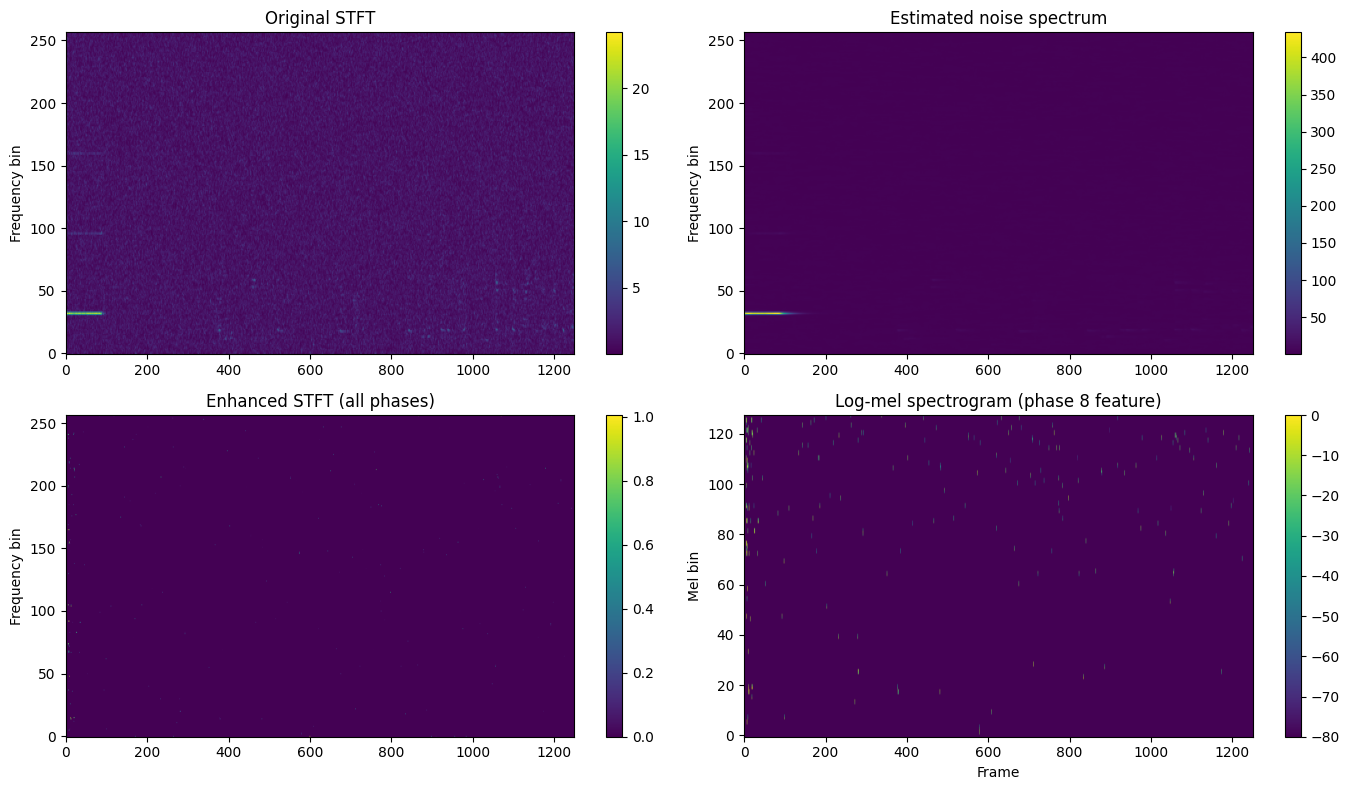

In [ ]:
if audio_files and audio is not None:
    # Build a synthetic 4-channel clip from a short excerpt. The full recording
    # is ~9500s; a 4-channel copy of the whole array (~5GB) plus several STFTs
    # would risk OOM on Colab, so the demo is capped to a short window.
    n_channels = 4
    demo_duration_sec = 10.0
    audio_demo = audio[:int(demo_duration_sec * sr)]
    multi_channel_demo = np.array([
        audio_demo + 0.1 * np.random.randn(len(audio_demo))
        for _ in range(n_channels)
    ])
    print(f"Demo multi-channel audio: {multi_channel_demo.shape} "
          f"({multi_channel_demo.shape[1] / sr:.2f}s)")

    try:
        pipeline_result = run_complete_dsp_pipeline(multi_channel_demo, sr=16000)
        print("\nOutput features:")
        for key, value in pipeline_result["features"].items():
            if isinstance(value, np.ndarray):
                print(f"  {key}: {value.shape}")

        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        panels = [
            ("stft", "Original STFT", axes[0, 0]),
            ("noise_spectrum", "Estimated noise spectrum", axes[0, 1]),
            ("enhanced_stft", "Enhanced STFT (all phases)", axes[1, 0]),
        ]
        for key, title, ax in panels:
            im = ax.imshow(pipeline_result[key], aspect="auto", origin="lower", cmap="viridis")
            ax.set_title(title)
            ax.set_ylabel("Frequency bin")
            plt.colorbar(im, ax=ax)

        im = axes[1, 1].imshow(pipeline_result["features"]["log_mel_spectrogram"],
                               aspect="auto", origin="lower", cmap="viridis")
        axes[1, 1].set_title("Log-mel spectrogram (phase 8 feature)")
        axes[1, 1].set_xlabel("Frame")
        axes[1, 1].set_ylabel("Mel bin")
        plt.colorbar(im, ax=axes[1, 1])

        plt.tight_layout()
        plt.show()
    except Exception as e:
        import traceback
        print(f"Error running pipeline: {e}")
        traceback.print_exc()
else:
    print("No audio data available. Load audio files first.")

## Export features to CSV (one file per split)

Each recording is processed in fixed-duration blocks (one `sample_id` per
block), labelling every frame from the speech mask derived from the transcript
timestamps. The loop is resumable: finished recordings are recorded in
`features/done_recordings.json` and blocks are appended to the split's CSV, so
re-running the cell resumes where it stopped.


In [ ]:
# Export parameters
BLOCK_DURATION_SEC = 30.0      # duration of each block (one sample_id per block)
HOP_LENGTH = 128               # must match the DSP feature extractor
MAX_BLOCKS_PER_SESSION = None  # None = whole session; e.g. 10 for a smoke test
OUT_DIR = CHIME6_ROOT / "features"   # one CSV per split: chime6_{train,dev,eval}.csv

OUT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = OUT_DIR / "done_recordings.json"  # resumability (Colab sessions drop)
done = set(json.loads(MANIFEST_PATH.read_text())) if MANIFEST_PATH.exists() else set()

block_samples = int(BLOCK_DURATION_SEC * SR)
frames_per_block = block_samples // HOP_LENGTH

for rec in recordings:
    rec_key = f"{rec['session_id']}_{rec['array']}"
    split = rec["split"]
    if rec_key in done:
        print(f"{rec_key} already processed - skipping")
        continue

    # Whole-session speech mask (1 = speech, 0 = noise) on the frame grid.
    speech_mask = build_speech_mask(
        rec["timestamps_start"], rec["timestamps_end"],
        rec["duration_sec"], hop_length=HOP_LENGTH, sr=SR,
    )

    n_blocks = int(rec["duration_sec"] * SR) // block_samples
    if MAX_BLOCKS_PER_SESSION is not None:
        n_blocks = min(n_blocks, MAX_BLOCKS_PER_SESSION)

    rec_features = []
    for block_idx in range(n_blocks):
        start = block_idx * block_samples

        # Load only this block from each real channel (never the full ~2.5h array).
        chans, ok = [], True
        for p in rec["channel_paths"]:
            data, _ = sf.read(p, start=start, stop=start + block_samples, dtype="float32")
            if data.ndim > 1:  # safety: collapse to first channel if multi-channel
                data = data[:, 0]
            if len(data) < block_samples:
                ok = False
                break
            chans.append(data)
        if not ok:
            break

        multi_channel = np.stack(chans, axis=0)  # (4, block_samples), real channels
        res = run_complete_dsp_pipeline(multi_channel, sr=SR, verbose=False)
        feat = res["features"]

        n_frames = feat["log_mel_spectrogram"].shape[1]
        frame_offset = block_idx * frames_per_block
        feat["labels"] = speech_mask[frame_offset:frame_offset + n_frames]
        feat["sample_id"] = f"{rec_key}_block_{block_idx:04d}"  # provenance: session + array + block
        rec_features.append(feat)

    if not rec_features:
        print(f"  Warning: {rec_key} produced no blocks")
        continue

    csv_path = OUT_DIR / f"chime6_{split}.csv"
    append = csv_path.exists() and csv_path.stat().st_size > 0
    export_features_to_csv(rec_features, csv_path, hop_length=HOP_LENGTH, sr=SR, append=append)

    done.add(rec_key)
    MANIFEST_PATH.write_text(json.dumps(sorted(done)))
    print(f"{rec_key} [{split}]: {len(rec_features)} blocks | "
          f"session speech {100.0 * speech_mask.mean():.1f}%")

# Sanity check: open each split CSV and confirm shapes / feature_dim.
for split in SPLITS:
    csv_path = OUT_DIR / f"chime6_{split}.csv"
    if not csv_path.exists():
        continue
    store = FeatureStore(csv_path)
    loader = build_dataloader(store, window_size=64, batch_size=4)
    print(f"\n[{split}] {csv_path}")
    print(f"  feature_dim = {store.feature_dim} | blocks (sample_ids) = {len(store.sample_ids())}")
    for batch_x, batch_y in loader:
        print(f"  Batch X {tuple(batch_x.shape)} | y {tuple(batch_y.shape)} | "
              f"speech fraction {batch_y.mean().item():.2f}")
        break

## Exported CSV schema (`chime6_{train,dev,eval}.csv`)

Source: **official CHiME-6 (OpenSLR-150)**. For each session one reference Kinect
array (4 real channels) is used. There is one CSV per official split, in
`CHIME6_ROOT/features/`. Each row is one time frame (128-sample hop at 16 kHz =
8 ms per frame).

| Column | Dim | Description |
|---|---|---|
| `sample_id` | 1 | Source block: `S0X_U0Y_block_NNNN` (session + array + block) |
| `timestamp_ms` | 1 | Time in ms relative to the block start |
| `log_mel_0..127` | 128 | Log-mel spectrogram (dB), per-feature z-score |
| `spatial_0..3` | 4 | Per-channel energy, 4 real Kinect channels, per-feature z-score |
| `label` | 1 | 1 = speech, 0 = noise/silence (from transcript start/end times) |

**Total `feature_dim = 132`** -> the `input_dim` of the LSTM.

The linear-magnitude beamformed STFT (257 cols) is computed internally (phase 8)
but not exported: the log-mel is a mel-filtered, log-scaled compaction of the
same spectral information (389 -> 132).

### Using it in the LSTM notebook
- Load each split: `store = FeatureStore("chime6_train.csv")` (same for dev/eval).
- `CHIME6LSTMDataset` returns `(X, y)`: `X` is `(window_size, 132)` for an
  `nn.LSTM` (`batch_first=True`); `y` is the 0/1 label of the last frame,
  matching a many-to-one `lstm_out[:, -1, :]`.
- Use `nn.BCEWithLogitsLoss` (the output dim is 1). Features are already
  normalized, so no extra scaling/inverse-transform is needed.
- `window_size` and `stride` are free hyperparameters; `sample_id` only ensures
  windows never cross a block boundary.
- Train/val/test = the three split CSVs. Within a split, sub-partition by
  `sample_id` via the `sample_ids` argument of `CHIME6LSTMDataset`.

### Scale and resumability
- `train` (~40h) produces a large CSV (millions of rows); prefer a high-RAM
  runtime and/or export to Parquet (keeps float32 and compresses better).
- The export loop is resumable via `features/done_recordings.json` and appends.
- `MAX_BLOCKS_PER_SESSION` and `SPLITS` control the amount of processing.
